In [1]:
#importing the necessary libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('uber-raw-data-janjune-15.csv') # reading the csv file
df.head(5) 

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-17 09:47:00,B02617,141
1,B02617,2015-05-17 09:47:00,B02617,65
2,B02617,2015-05-17 09:47:00,B02617,100
3,B02617,2015-05-17 09:47:00,B02774,80
4,B02617,2015-05-17 09:47:00,B02617,90


# Q1

#Summarize data (df.groupby) by Dispatching_base_num and locationID.

In [3]:
df.groupby(['Dispatching_base_num','locationID']).count()
# reference :- https://sparkbyexamples.com/pandas/pandas-groupby-count-examples/

Pickup_date  Affiliated_base_num
Dispatching_base_num locationID                                  
B02512               1                     3                    3
                     3                    23                   21
                     4                  1233                 1205
                     5                     1                    1
                     6                    23                   23
...                                      ...                  ...
B02836               258                   2                    2
                     260                  11                   11
                     261                   4                    4
                     262                   4                    4
                     263                  13                   13

[1946 rows x 2 columns]

# Q2

Which locationID has the highest count?

In [4]:
a = df.groupby('locationID').size().sort_values().tail(1) 
print("The highest count in location id is: ", a)
#https://stackoverflow.com/questions/10373660/converting-a-pandas-groupby-output-from-series-to-dataframe

The highest count in location id is:  locationID
161    460732
dtype: int64


# Q3

Which Dispatching_base_num appeared maximum time?

In [5]:
# Dispatching_base_num  appeared maximum time
d = df.groupby('Dispatching_base_num').size().sort_values().tail(1)
print(d)
print("Dispatching_base_num appeared maximum time is: ", d[0])
# Refrence:- https://stackoverflow.com/questions/22291395/sorting-the-grouped-data-as-per-group-size-in-pandas

Dispatching_base_num
B02764    5753653
dtype: int64
Dispatching_base_num appeared maximum time is:  5753653


# Q4

Which three dates have the highest traffic? Which days (Mon, Tue?) were these (find this programmatically).

In [6]:
#This are three dates have the highest pick_up dates
df.groupby('Pickup_date').size().sort_values().tail(3)

Pickup_date
2015-06-27 21:36:00    210
2015-06-27 20:52:00    213
2015-06-27 22:19:00    213
dtype: int64

In [7]:
# To know which three dates have the highest traffic
def findDay(date):
    born = datetime.datetime.strptime(date, '%Y-%m-%d').weekday()
    return (calendar.day_name[born])

x = (df.groupby('Pickup_date').size().sort_values().tail(3)).index
# Refrence:- https://www.geeksforgeeks.org/python-program-to-find-day-of-the-week-for-a-given-date/

In [8]:
import datetime #importing the necessary libraries
import calendar
for i in x:
    z = i, findDay(i[:10])
    print(' The date when there is more traffic',z[0],"and day is ", z[1])
# Refrence: - https://www.geeksforgeeks.org/python-program-to-find-day-of-the-week-for-a-given-date/

 The date when there is more traffic 2015-06-27 21:36:00 and day is  Saturday
 The date when there is more traffic 2015-06-27 20:52:00 and day is  Saturday
 The date when there is more traffic 2015-06-27 22:19:00 and day is  Saturday


# Q5

How many dispatching_bases are there?

In [9]:
print(df.Dispatching_base_num.unique()) # Finding the unique values 
print("The length of Dispatching_base_num is:", len(df.Dispatching_base_num.unique())) # Length of the unique values

['B02617' 'B02598' 'B02682' 'B02764' 'B02512' 'B02765' 'B02835' 'B02836']
The length of Dispatching_base_num is: 8


# Q6

Summarize data per day (eliminate time) and plot the number of pickups per day. If days are too many, summarize per week.

In [10]:
# The dates are seperated from data and time
df['Dates'] = pd.to_datetime(df['Pickup_date']).dt.date
# Refrence:- https://www.geeksforgeeks.org/how-to-convert-datetime-to-date-in-pandas/

In [11]:
df.head() # To check wheather date column is added or not.

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,Dates
0,B02617,2015-05-17 09:47:00,B02617,141,2015-05-17
1,B02617,2015-05-17 09:47:00,B02617,65,2015-05-17
2,B02617,2015-05-17 09:47:00,B02617,100,2015-05-17
3,B02617,2015-05-17 09:47:00,B02774,80,2015-05-17
4,B02617,2015-05-17 09:47:00,B02617,90,2015-05-17


<AxesSubplot:xlabel='Dates'>

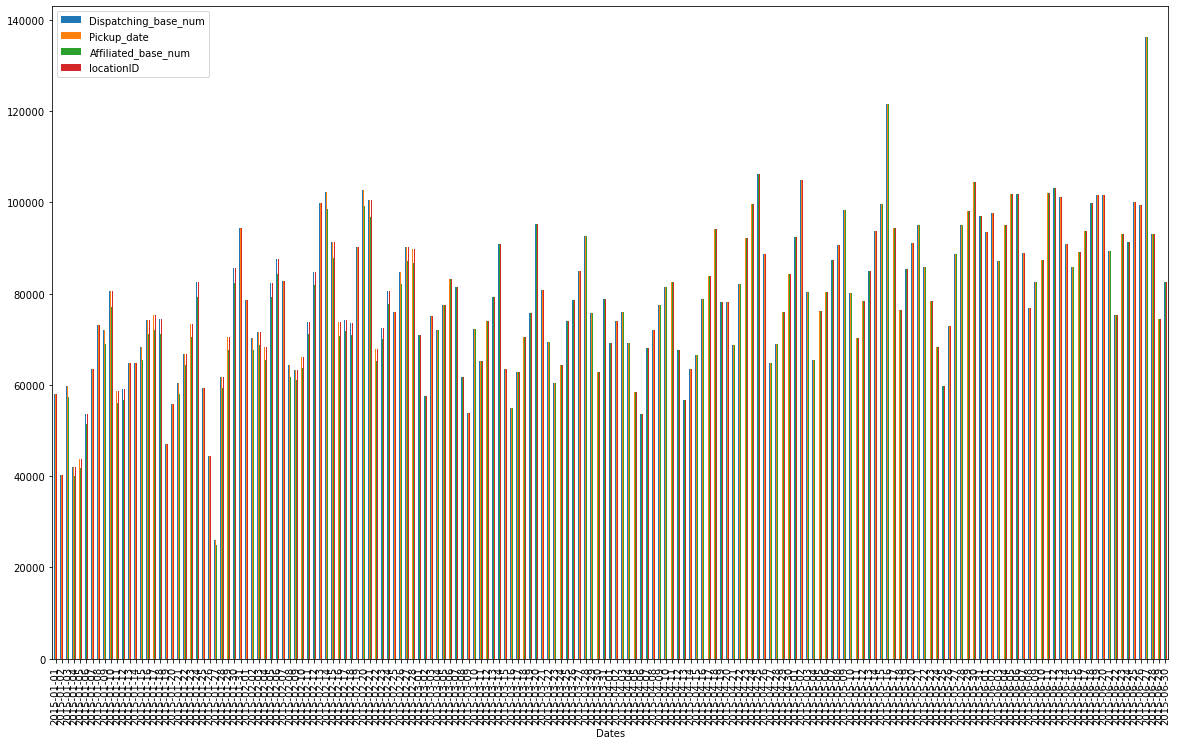

In [12]:
df.groupby('Dates').count().plot(kind = 'bar', figsize = (20,12))

# Q7
Is there an Affiliated_base_num which has some interesting statistics (most people visit it on a certain day of the week?)


In [13]:
df.Affiliated_base_num.info() # Getting the information from 

<class 'pandas.core.series.Series'>
RangeIndex: 14270479 entries, 0 to 14270478
Series name: Affiliated_base_num
Non-Null Count     Dtype 
--------------     ----- 
14108284 non-null  object
dtypes: object(1)
memory usage: 108.9+ MB


<AxesSubplot:ylabel='Density'>

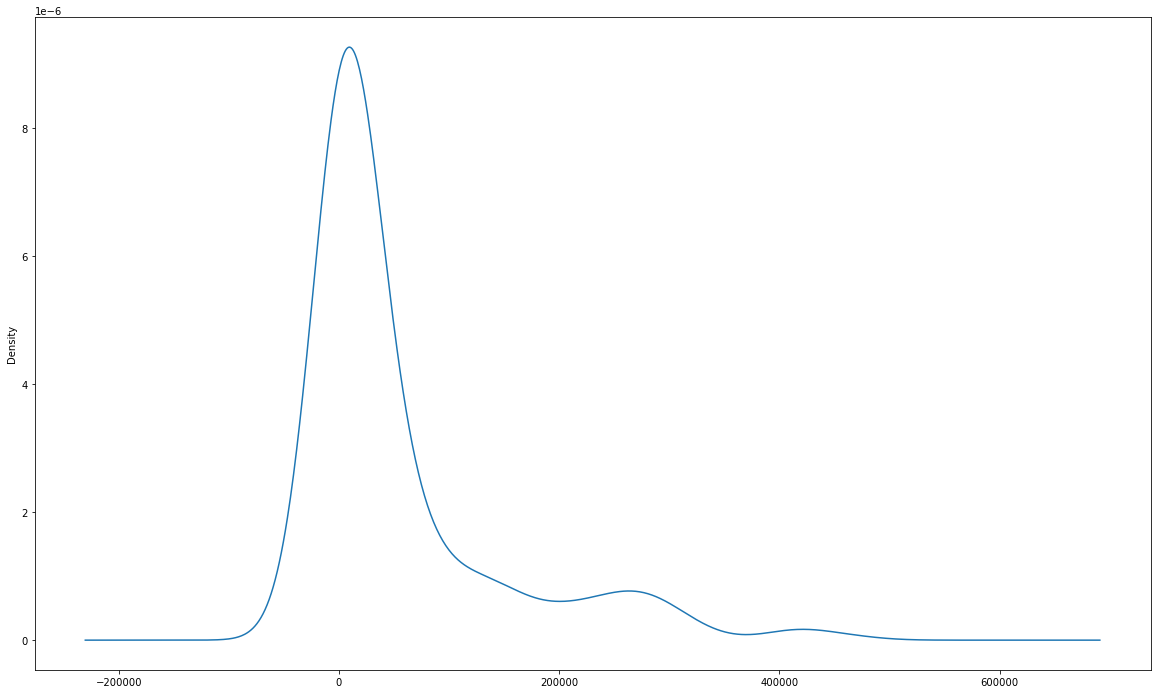

In [14]:
df.groupby('locationID').size().sort_values().plot(kind = 'kde', figsize = (20,12))
# Reference:- https://mode.com/python-tutorial/counting-and-plotting-in-python/

# Q7
Plot in various formats, even if it is the same data. Use colors and fancy charts.

In [ ]:
#df.groupby('locationID').size().sort_values().plot(kind = 'bar', figsize = (50,35), marker='o') 
# I altered the formats using the identical information from the previous cell. 

<AxesSubplot:ylabel='Density'>

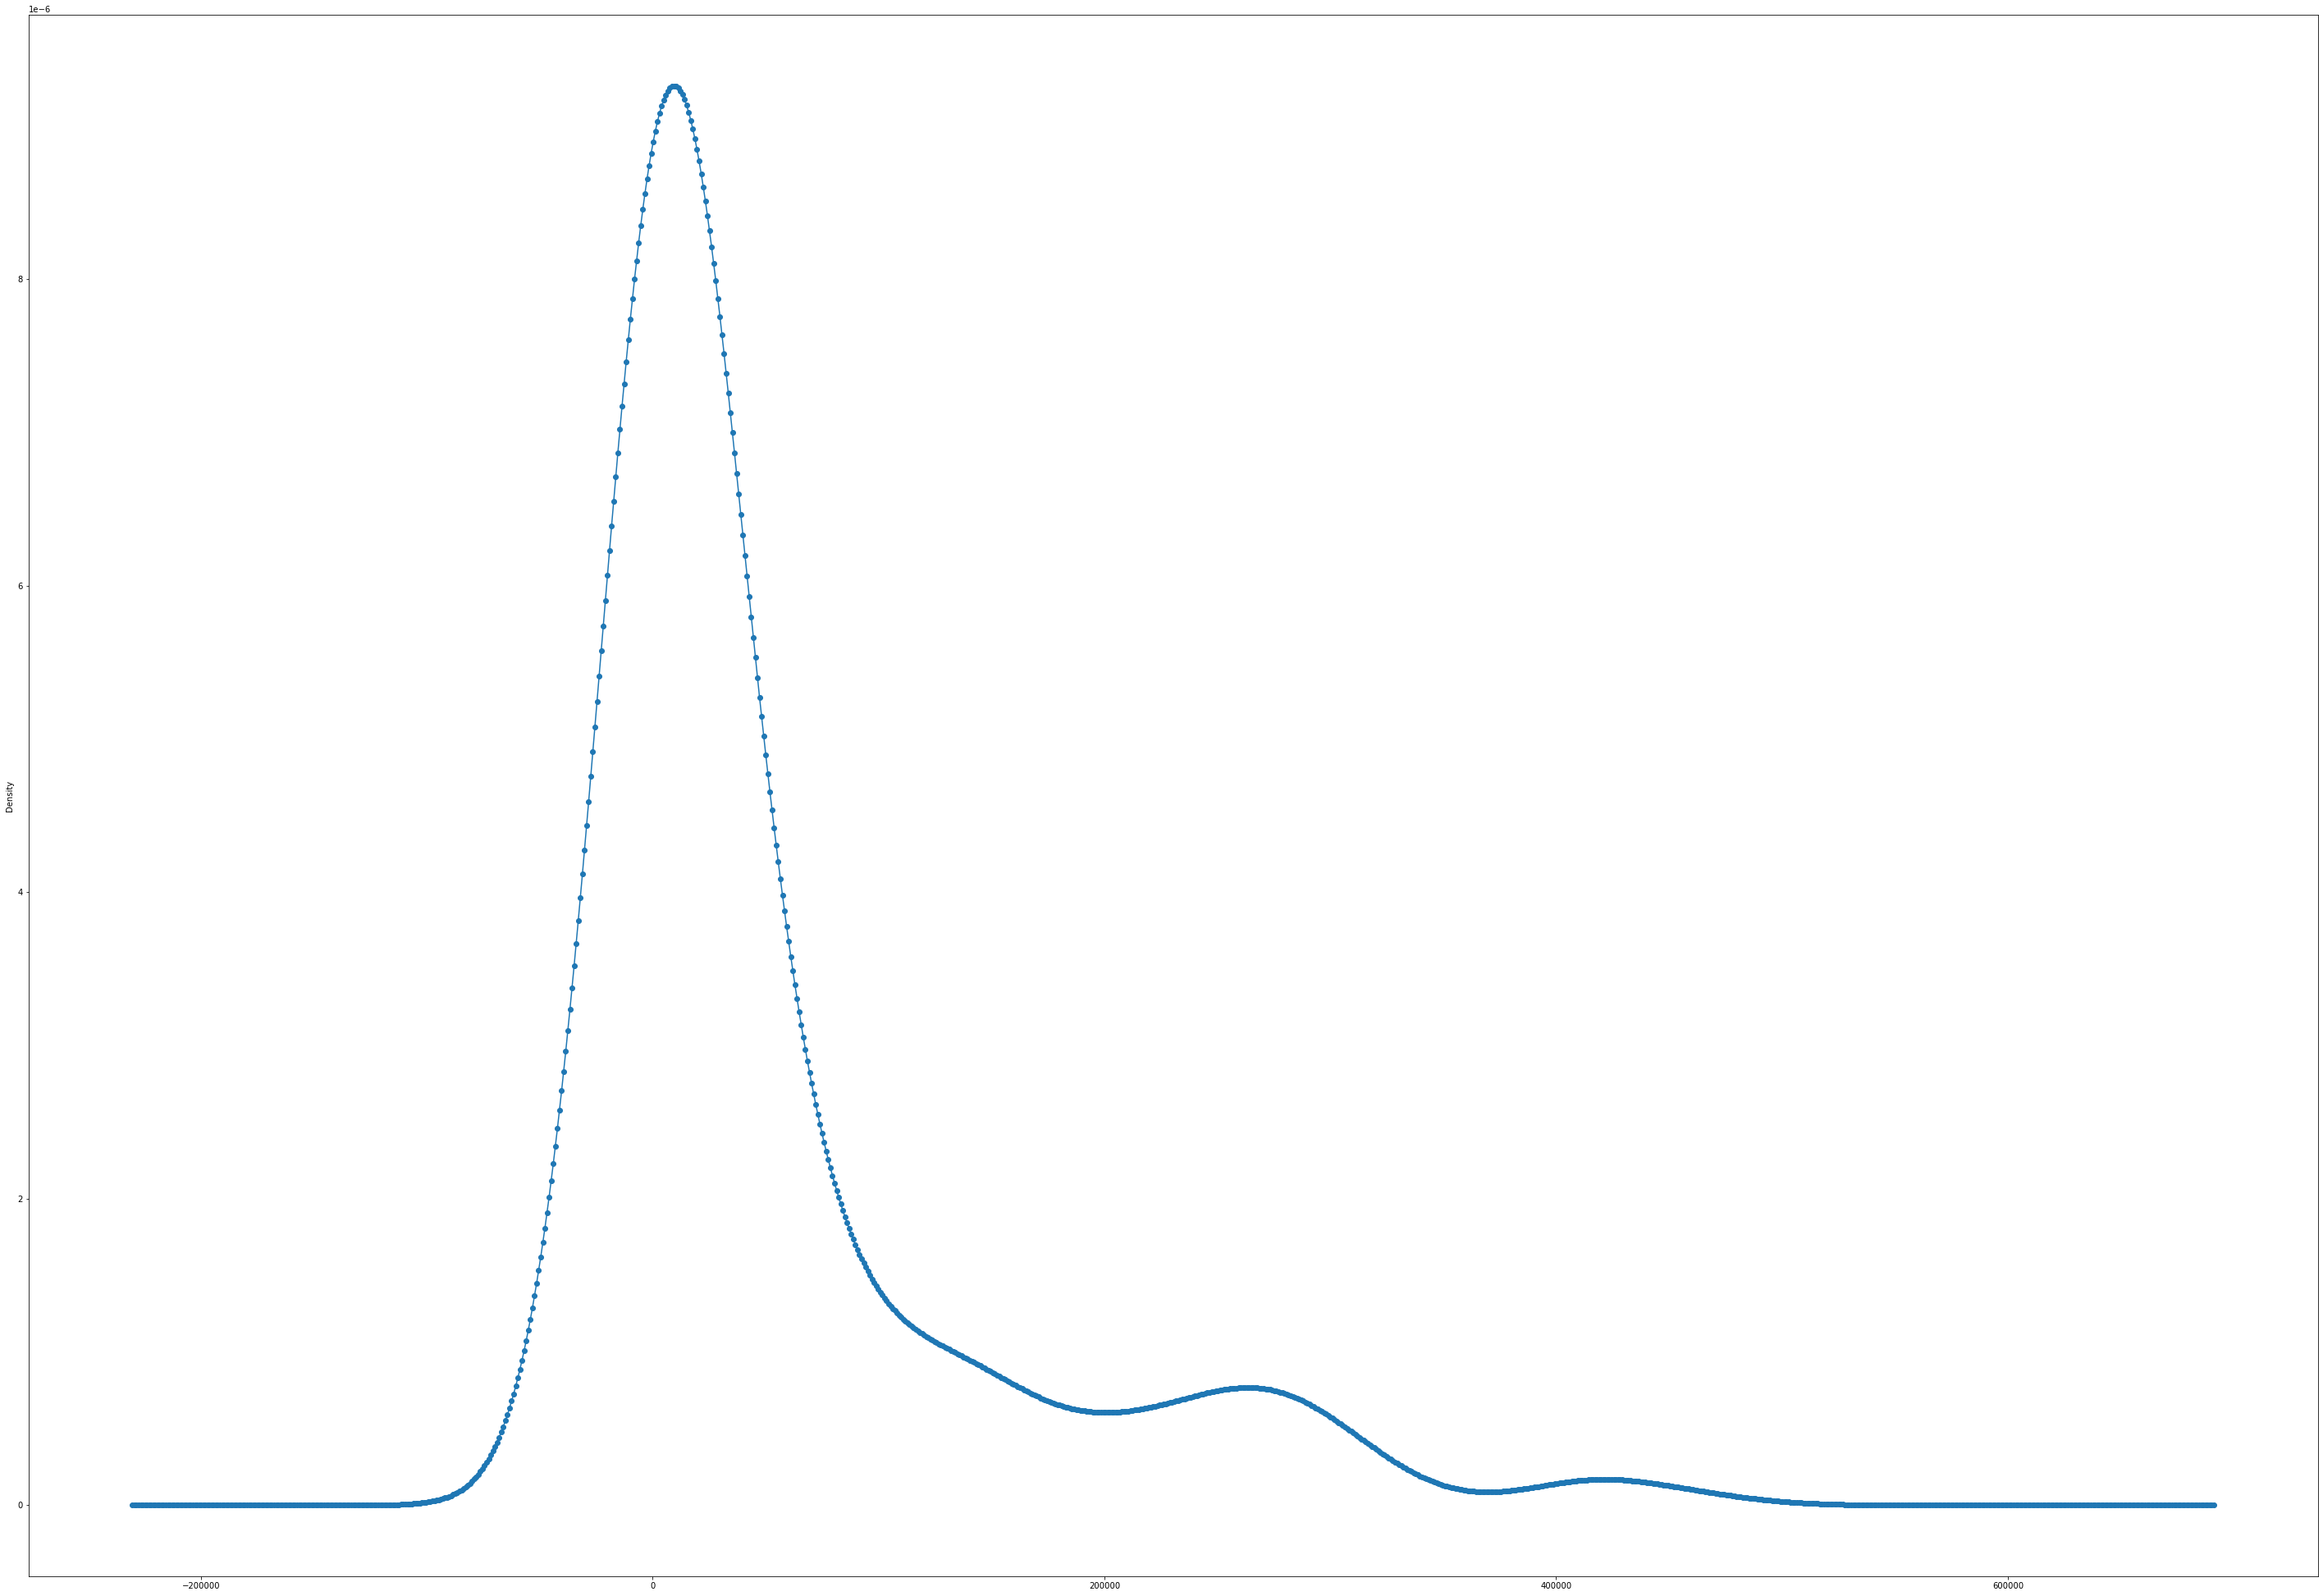

In [16]:
df.groupby('locationID').size().sort_values().plot(kind = 'kde', figsize = (50,35), marker='o')

# Q8
The idea is to explore this data and discover interesting pieces of information which you would like to discover.


In [17]:
df.isnull().sum() # Checking any columns in the data have null values

Dispatching_base_num         0
Pickup_date                  0
Affiliated_base_num     162195
locationID                   0
Dates                        0
dtype: int64

In [18]:
df['Affiliated_base_num'].unique() # Getting unique values

array(['B02617', 'B02774', 'B02764', 'B02682', 'B02765', 'B00272',
       'B02401', 'B01087', 'B01197', 'B02512', 'B02729', 'B00227', nan,
       'B02598', 'B00013', 'B02003', 'B00628', 'B02818', 'B00254',
       'B02715', 'B01998', 'B02207', 'B02101', 'B02789', 'B02510',
       'B00412', 'B00111', 'B00477', 'B02806', 'B00448', 'B02664',
       'B02788', 'B01949', 'B02067', 'B00271', 'B02534', 'B02285',
       'B00837', 'B02770', 'B00277', 'B01877', 'B02522', 'B00014',
       'B00789', 'B02216', 'B01875', 'B02749', 'B02406', 'B00296',
       'B02507', 'B02787', 'B00053', 'B02345', 'B02670', 'B02822',
       'B01976', 'B00381', 'B00446', 'B02651', 'B02763', 'B01899',
       'B02732', 'B02016', 'B01913', 'B02588', 'B02644', 'B02835',
       'B02783', 'B02836', 'B02725', 'B02382', 'B02453', 'B02225',
       'B02772', 'B00888', 'B02499', 'B02815', 'B02712', 'B02277',
       'B02769', 'B02202', 'B02254', 'B02814', 'B00608', 'B02480',
       'B02847', 'B00235', 'B02780', 'B02776', 'B02472', 

In [19]:
df.Affiliated_base_num = df.Affiliated_base_num.fillna('not known') # Filling values

In [20]:
df['Affiliated_base_num'].unique() # checking to see if the null place is filled

array(['B02617', 'B02774', 'B02764', 'B02682', 'B02765', 'B00272',
       'B02401', 'B01087', 'B01197', 'B02512', 'B02729', 'B00227',
       'not known', 'B02598', 'B00013', 'B02003', 'B00628', 'B02818',
       'B00254', 'B02715', 'B01998', 'B02207', 'B02101', 'B02789',
       'B02510', 'B00412', 'B00111', 'B00477', 'B02806', 'B00448',
       'B02664', 'B02788', 'B01949', 'B02067', 'B00271', 'B02534',
       'B02285', 'B00837', 'B02770', 'B00277', 'B01877', 'B02522',
       'B00014', 'B00789', 'B02216', 'B01875', 'B02749', 'B02406',
       'B00296', 'B02507', 'B02787', 'B00053', 'B02345', 'B02670',
       'B02822', 'B01976', 'B00381', 'B00446', 'B02651', 'B02763',
       'B01899', 'B02732', 'B02016', 'B01913', 'B02588', 'B02644',
       'B02835', 'B02783', 'B02836', 'B02725', 'B02382', 'B02453',
       'B02225', 'B02772', 'B00888', 'B02499', 'B02815', 'B02712',
       'B02277', 'B02769', 'B02202', 'B02254', 'B02814', 'B00608',
       'B02480', 'B02847', 'B00235', 'B02780', 'B02776', 'B

In [21]:
df['Time'] = pd.to_datetime(df['Pickup_date']).dt.time # Separating the time from Pickup date by adding another column
df.head()

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,Dates,Time
0,B02617,2015-05-17 09:47:00,B02617,141,2015-05-17,09:47:00
1,B02617,2015-05-17 09:47:00,B02617,65,2015-05-17,09:47:00
2,B02617,2015-05-17 09:47:00,B02617,100,2015-05-17,09:47:00
3,B02617,2015-05-17 09:47:00,B02774,80,2015-05-17,09:47:00
4,B02617,2015-05-17 09:47:00,B02617,90,2015-05-17,09:47:00


<AxesSubplot:ylabel='Density'>

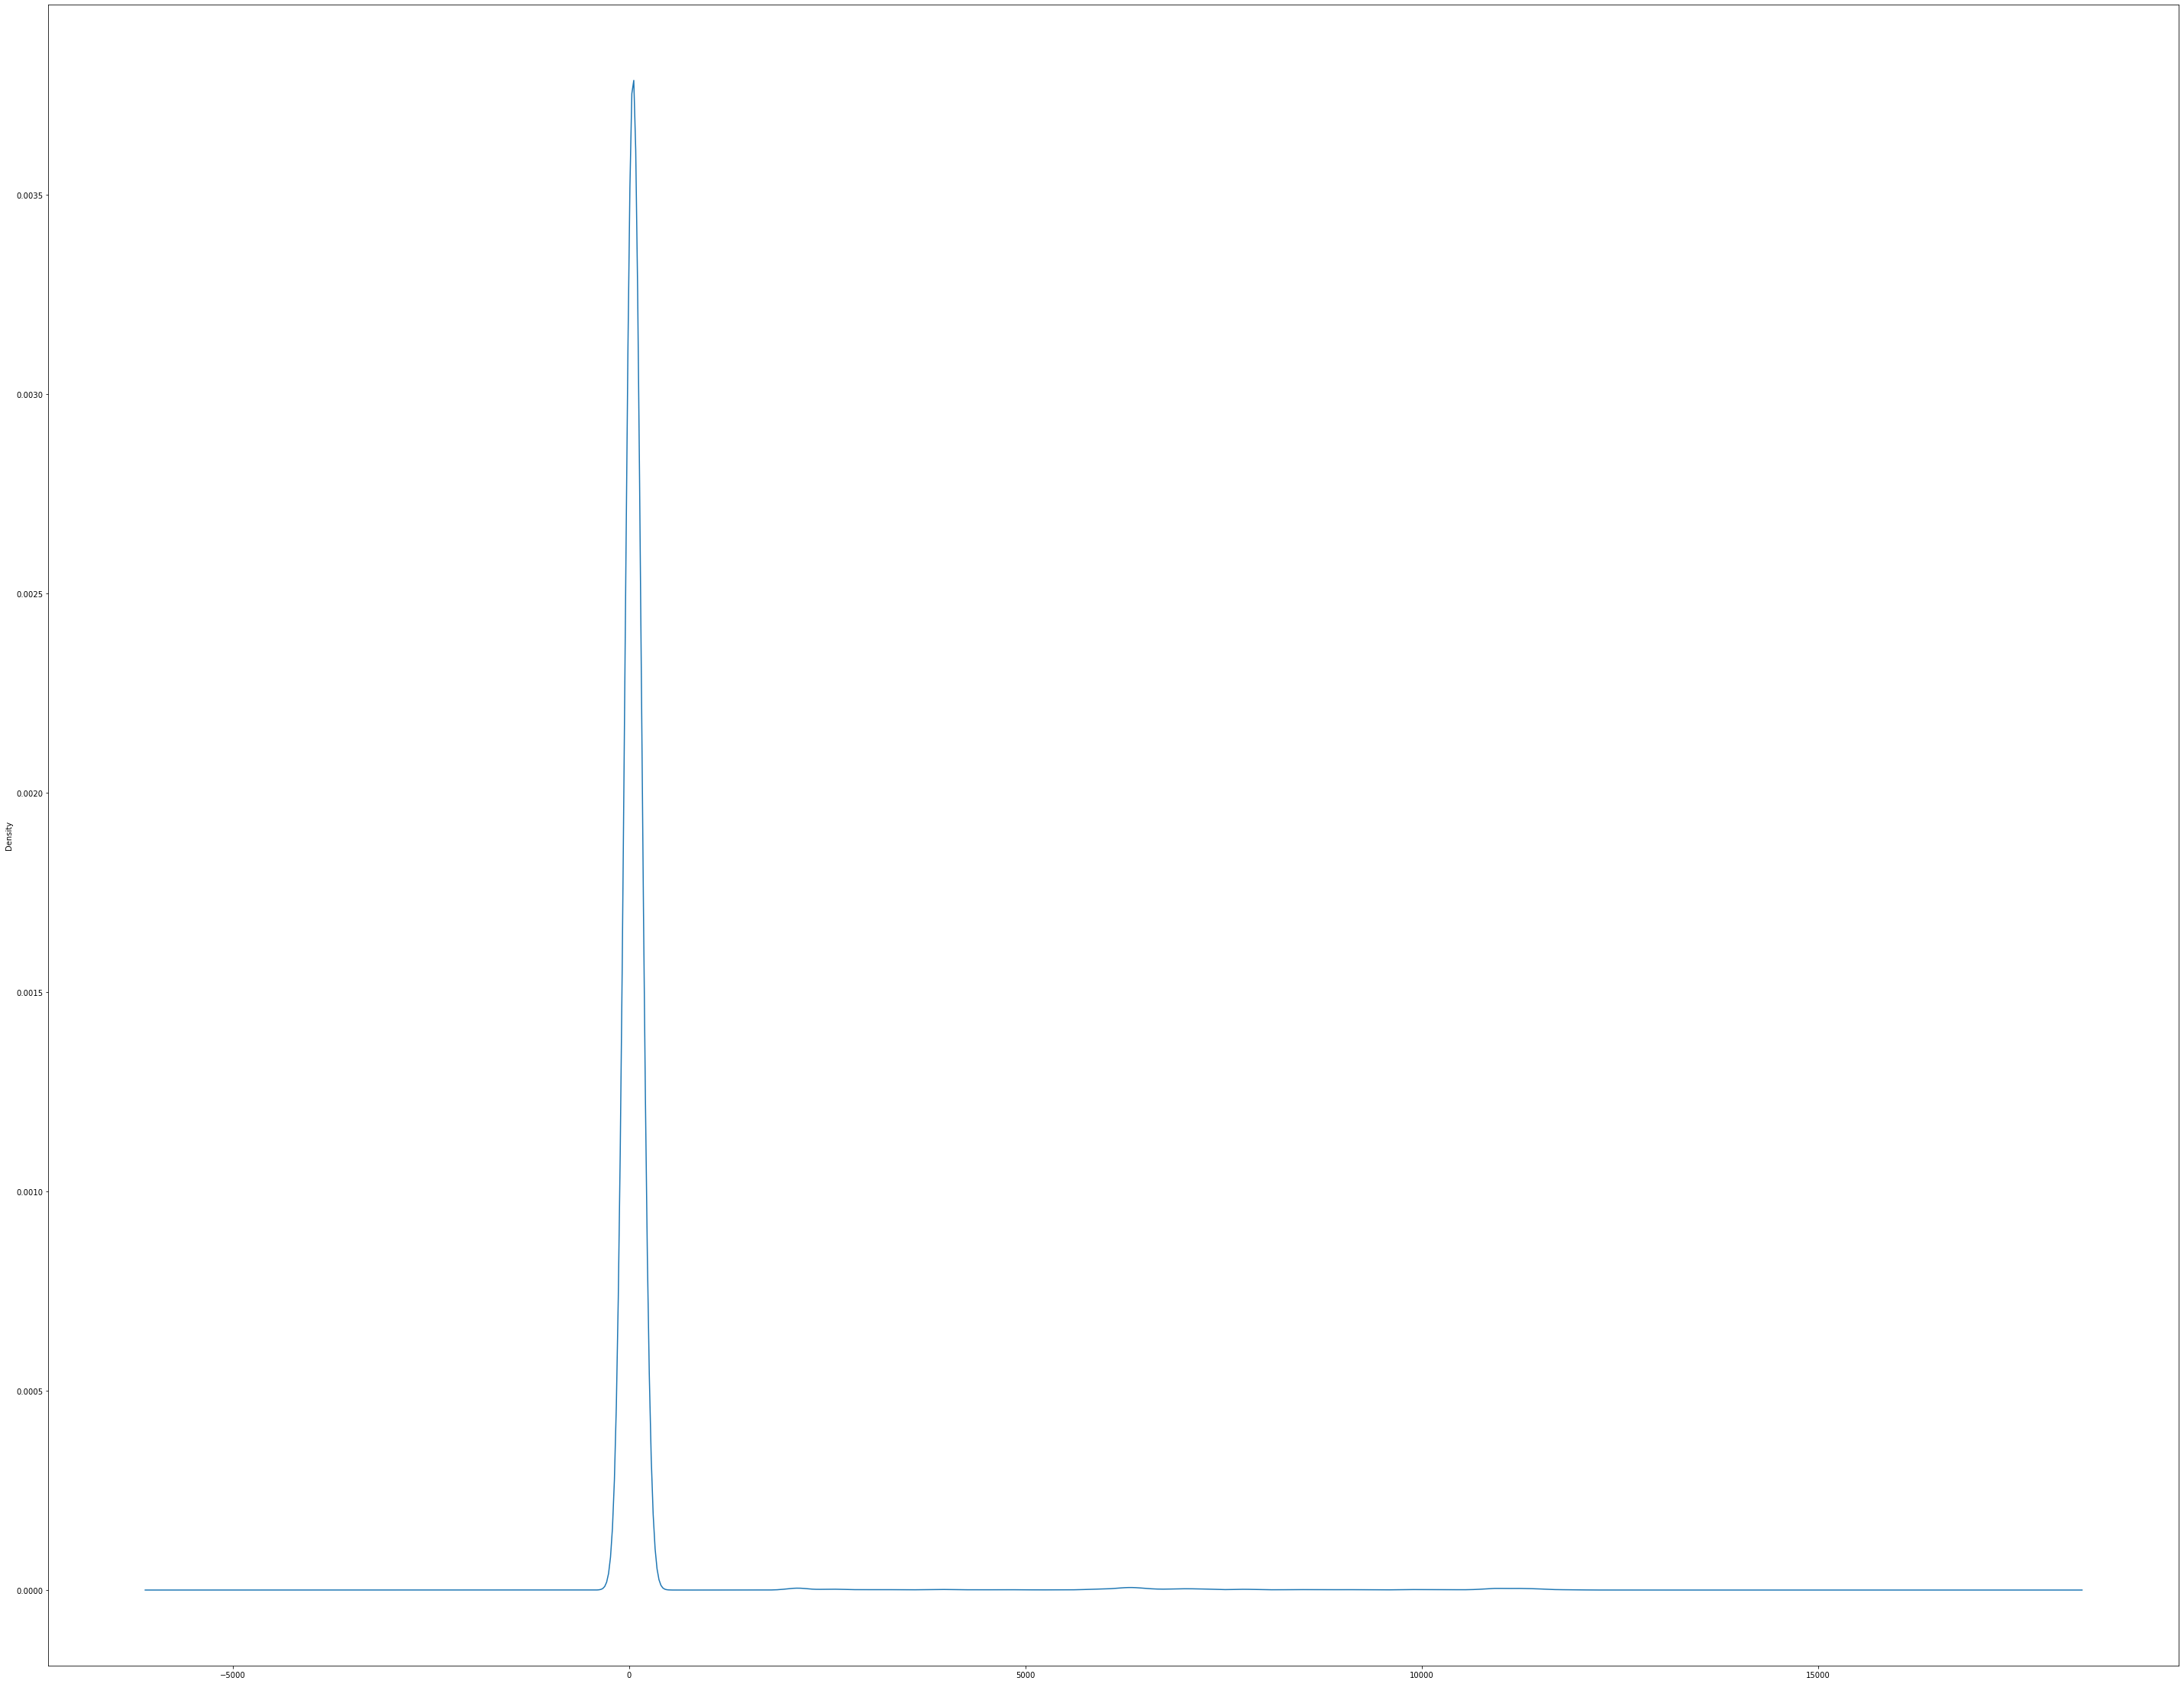

In [22]:
df.groupby('Time').size().sort_values().plot(kind = 'kde', figsize = (50,40))